In [6]:
import math

from neurotools import models
from neurotools import modules
import torch
from matplotlib import pyplot as plt
from torch.utils.data import Dataset, DataLoader

In [12]:
# create basic dataset
class ImageGeneratorDataset(Dataset):
    def __init__(self, num_samples=1000, noise=.2, label_min=0, label_max=5):
        self.num_samples = num_samples
        self.noise = noise
        self.label_min = label_min
        self.label_max = label_max

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # Generate a random label
        label = torch.randint(self.label_min, self.label_max, (1,)).item()

        if label == 0:
            # Generate an up/down cross image
            image = torch.tensor([[0, 1, 0, 0],
                                  [1, 1, 1, 1],
                                  [0, 1, 0, 0],
                                  [0, 1, 0, 0]])
        elif label == 1:
            # Generate a diagonal line image
            image = torch.tensor([[1, 0, 0, 0],
                                  [0, 1, 0, 0],
                                  [0, 0, 1, 0],
                                  [0, 0, 0, 1]])
        elif label == 2:
            # Generate a checkerboard image
            image = torch.tensor([[0, 1, 0, 1],
                                  [1, 0, 1, 0],
                                  [0, 1, 0 , 1],
                                  [1, 0, 1, 0]])
        elif label == 3:
            # Generate horizontal lines image
            image = torch.tensor([[1, 1, 1, 1],
                                  [0, 0, 0, 0],
                                  [1, 1, 1, 1],
                                  [0, 0, 0, 0]])
        else:
            # Generate a vertical line image
            image = torch.tensor([[0, 1, 0, 0],
                                  [0, 1, 0, 0],
                                  [0, 1, 0, 0],
                                  [0, 1, 0, 0]])

        image = image + torch.normal(size=image.shape, mean=0, std=self.noise)

        return image, label

In [ ]:
class CategoricalDistributor:
    """
    class that normally distributes a given number of classes over the surface of a unit hypersphere
    """
    def __init__(self, initial_classes):
        self.num_classes = 0
        self.loci = []
        self.names = []
        for name in initial_classes:
            self.add_class(name=name)

    def add_class(self, name=None):
        self.num_classes += 1
        locus = (torch.rand(size=(2,)) * 2) * torch.pi # range: 0, 2*pi
        self.loci.append(locus)
        self.names.append(name)

    def logits(self, polar):
        """
        :param polar: batch x 2 tensor of theta, psi spherical coordinates
        :return: batch x num_classes distance from each locus along surface.
        """
        polar = torch.remainder(polar, torch.pi * 2)
        theta = polar[:, 0]
        psi = polar[:, 1]
        arc = torch.acos(torch.sin(theta)*torch.sin(psi) + math.cos(theta) * math.cos(psi) * math.cos(theta - psi))
        return arc


In [13]:
train_dataset = ImageGeneratorDataset(label_min=0, label_max=3, noise=.1)
train_dataloader = DataLoader(dataset=train_dataset, batch_size=100, shuffle=True)

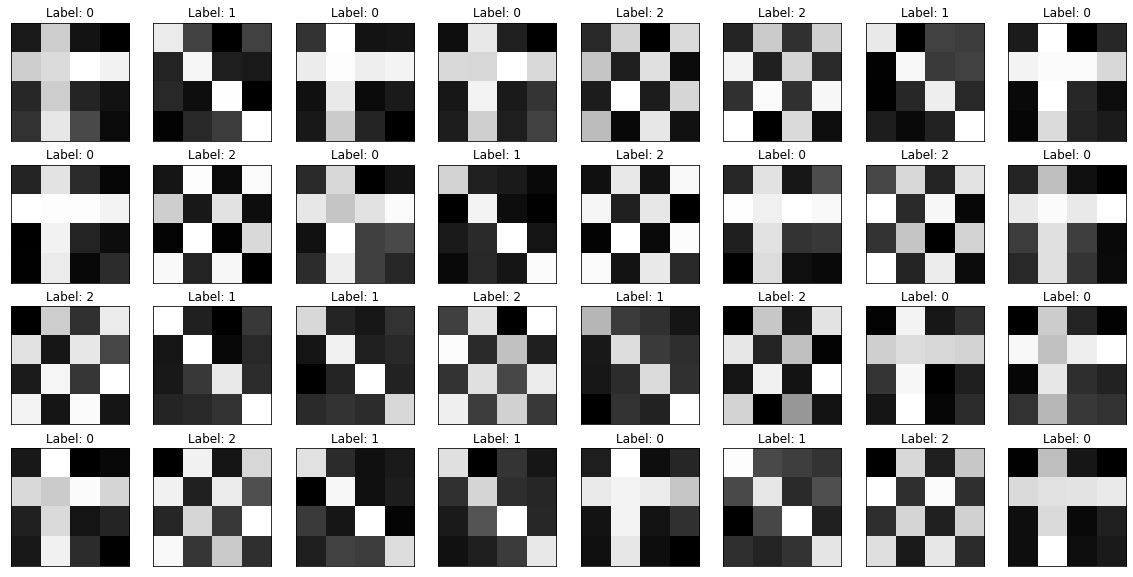

In [14]:
# view some images

# Get some images and labels from the dataloader
images, labels = next(iter(train_dataloader))

# Create a figure with subplots
fig, axs = plt.subplots(nrows=4, ncols=8, figsize=(20, 10))

# Iterate over the subplots and plot the images
for i, ax in enumerate(axs.flat):
    # Get the image and label
    image, label = images[i], labels[i]

    # Plot the image
    ax.imshow(image, cmap='gray')

    # Set the title to the label
    ax.set_title(f'Label: {label.item()}')

    # Remove the axis labels
    ax.set_xticks([])
    ax.set_yticks([])

# Show the plot
plt.show()

In [ ]:
# create a small reverb network
revnet = models.ElegantReverbNetwork(num_nodes=3, input_nodes=(0,), node_shape=(1, 3, 4, 4), edge_module=modules.ElegantReverb, device='cuda', mask=torch.ones((4, 4), device='cuda'))
revnet_decoder = torch.nn.Sequential(torch.nn.MaxPool2d(2),
                                     torch.nn.Conv2d(kernel_size=2, in_channels=3, out_channels=1, device="cpu", bias=False))
revnet_dist = CategoricalDistributor(initial_classes=["cross", "slash", "checker"])

In [ ]:
present_frames = 5
optimizer = torch.optim.Adam(lr=.01, params=list(revnet_decoder.parameters()) + list(revnet.parameters()))
ce_loss = torch.nn.NLLLoss()

In [ ]:
# we need a continuous decoder, for now we'll use a unit circle, and consider the output of the models as arclength from the origin

In [15]:
# schema
# (in)
# |s| --> |a| -- |b| <--loss
#           \   /        |
#            |c| --> decoder
#           (out)

history = []
for epoch in range(1000):
    for i, (stims, targets) in enumerate(train_dataloader):
        local_history = []
        optimizer.zero_grad()
        revnet.detach(reset_intrinsic=False)
        for stim, target in list(zip(stims, targets)):
            for _ in range(present_frames):
                revnet(stim.to("cuda"))
            decode_input = revnet.states[2, 0, :, :][None, None, :, :].clone()
            polar = revnet_decoder(decode_input)
            logits = revnet_dist.logits(polar)
            y_hat = torch.log_softmax(logits, dim=1)
            target = target.long().to("cuda")
            # insert loss information
            local_history.append(y_hat.clone())
        lh = torch.cat(local_history[-100:])
        lt = torch.cat(targets[-100:])
        loss = ce_loss(lh, lt)
        acc = torch.count_nonzero(torch.argmax(lh, dim=1) == lt)
        print("EPOCH:", epoch)
        print(loss.detach().cpu().item())
        print(acc.detach().cpu().item())
        loss.backward()
        optimizer.step()
    history.append(acc.detach().cpu().item())

plt.plot(history)
plt.show()